# HDI Cross-Country Analysis (2022): A Multi-Source Data Pipeline & Structural Audit
## Notebook 04: Statistical Analysis

**Goal:** Verify signal consistency across the integrated multi-source dataset using OLS regression as a diagnostic tool. Outputs should be interpreted as associative diagnostics, not causal findings.

**Input:** `processed_data/master_dataset.csv`
Analytical workflow

1. Log transformation for normalization
2. Correlation analysis audit
3. Multicollinearity assessment (VIF)
4. Validation OLS regression
5. Model diagnostics
6. Standardized coefficients (Component Attribution)
7. Integrity interpretation and production readiness

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Statistical libraries
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats

BASE_DIR = Path("..").resolve()
PROCESSED_DATA = BASE_DIR / "processed_data"

# Load master dataset
master = pd.read_csv(PROCESSED_DATA / "master_dataset.csv")

print(f"Shape: {master.shape}")

Shape: (186, 11)


In [2]:
master 

,country_code,country,hdi,gdp_per_capita,mean_years_schooling,education_expenditure_pct_gdp,health_expenditure_per_capita,government_effectiveness,gii,region,income_level
0,AFG,Afghanistan,0.462,377.665627,2.514790,NaN,80.651604,-1.880035,0.665,Middle East & North Africa,Low income
1,AGO,Angola,0.591,2860.902519,5.844292,2.385359,103.945061,-1.026034,0.520,Sub-Saharan Africa,Lower middle income
2,ALB,Albania,0.789,5867.650962,10.121144,2.729770,506.869202,0.064541,0.116,Europe & Central Asia,Upper middle income
3,AND,Andorra,0.884,39780.415299,11.613440,2.647280,3190.113281,1.495261,NaN,Europe & Central Asia,High income
4,ARE,United Arab Emirates,0.937,41828.555330,12.773750,NaN,2240.905029,1.299128,0.035,Middle East & North Africa,High income
...,...,...,...,...,...,...,...,...,...,...,...
181,VUT,Vanuatu,0.614,2740.275455,7.183210,10.703346,136.795090,-0.538525,NaN,East Asia & Pacific,Lower middle income
182,WSM,Samoa,0.702,4095.158683,11.367356,6.159788,259.954041,0.307864,0.406,East Asia & Pacific,Upper middle income
183,ZAF,South Africa,0.717,5786.865053,11.606970,6.155990,570.480286,-0.109028,0.401,Sub-Saharan Africa,Upper middle income
184,ZMB,Zambia,0.569,1298.848050,7.284893,3.658841,75.401283,-0.638017,0.526,Sub-Saharan Africa,Lower middle income


## I Log Transformation


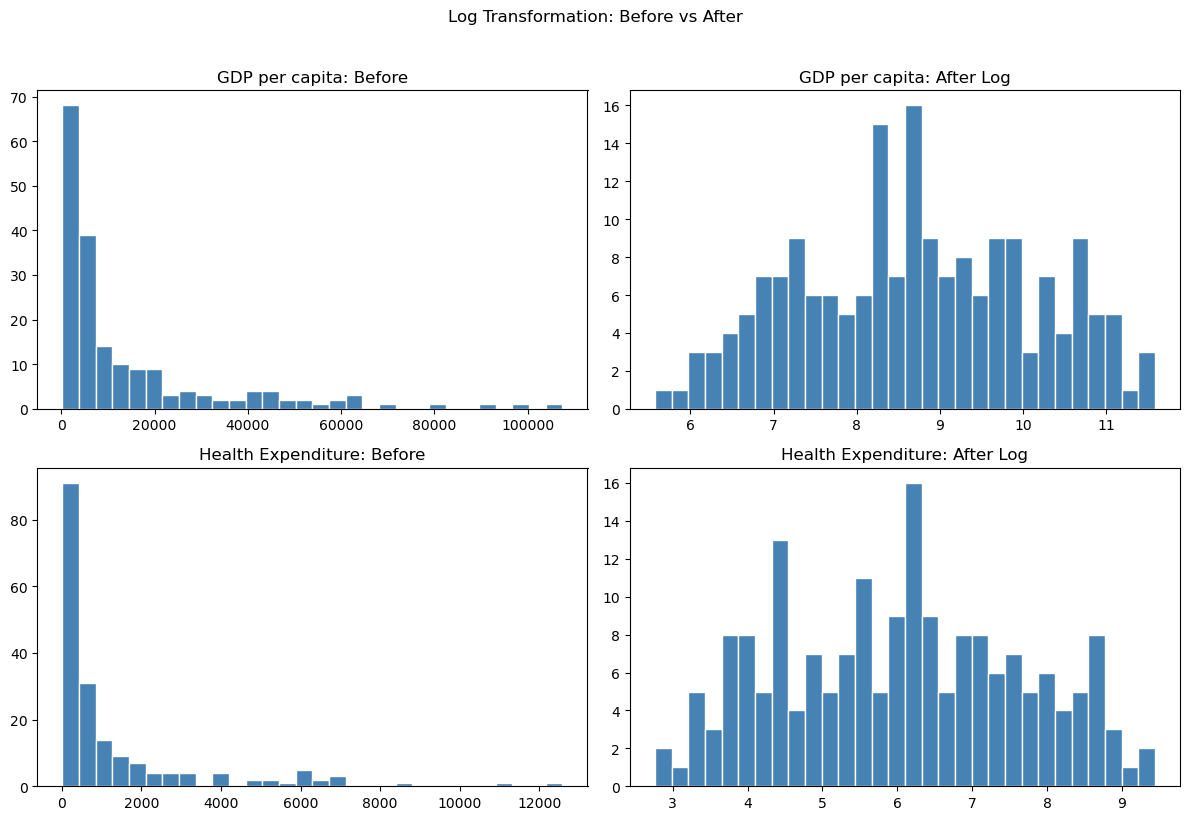

In [14]:
# Apply log transformation to skewed variables
master['log_gdp_per_capita'] = np.log(master['gdp_per_capita'])
master['log_health_expenditure'] = np.log(master['health_expenditure_per_capita'])

# Verify transformation 
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].hist(master['gdp_per_capita'].dropna(), bins=30, color='steelblue', edgecolor='white')
axes[0, 0].set_title('GDP per capita: Before')

axes[0, 1].hist(master['log_gdp_per_capita'].dropna(), bins=30, color='steelblue', edgecolor='white')
axes[0, 1].set_title('GDP per capita: After Log')

axes[1, 0].hist(master['health_expenditure_per_capita'].dropna(), bins=30, color='steelblue', edgecolor='white')
axes[1, 0].set_title('Health Expenditure: Before')

axes[1, 1].hist(master['log_health_expenditure'].dropna(), bins=30, color='steelblue', edgecolor='white')
axes[1, 1].set_title('Health Expenditure: After Log')

plt.suptitle('Log Transformation: Before vs After', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## II. Correlation analysis audit


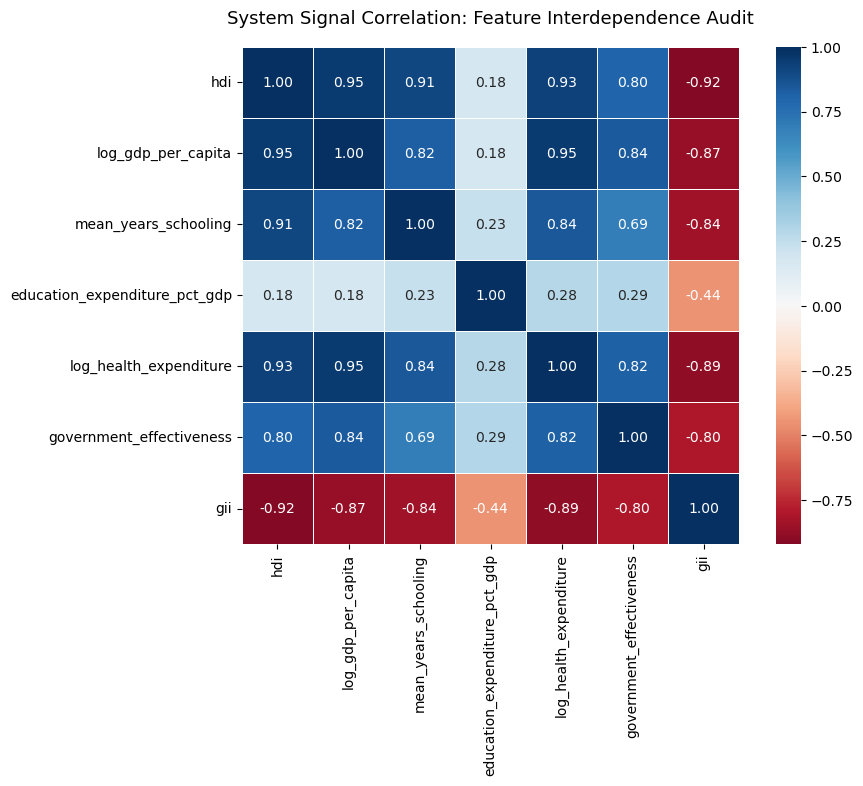

In [15]:
# Correlation Heatmap
validation_features = [
    'hdi',                          # Target Signal
    'log_gdp_per_capita',           # Economic Pillar
    'mean_years_schooling',         # Education Pillar
    'education_expenditure_pct_gdp',# Secondary Signal
    'log_health_expenditure',       # Secondary Signal
    'government_effectiveness',     # Governance Signal
    'gii'                           # Inequality Signal
]

# Create the focused matrix
corr_matrix = master[validation_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f',
            cmap='RdBu', 
            center=0,
            square=True,
            linewidths=0.5)

plt.title('System Signal Correlation: Feature Interdependence Audit', fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

## III Multicollinearity Assessment (VIF)


In [5]:
# Prepare variables for VIF analysis 
vif_vars = ['log_gdp_per_capita', 'mean_years_schooling',
            'education_expenditure_pct_gdp', 'log_health_expenditure',
            'government_effectiveness', 'gii']

# Drop rows with missing values for VIF calculation
vif_data = master[vif_vars].dropna()

# Calculate VIF
vif_results = pd.DataFrame()
vif_results['variable'] = vif_vars
vif_results['VIF'] = [variance_inflation_factor(vif_data.values, i) 
                       for i in range(len(vif_vars))]

print(vif_results.sort_values('VIF', ascending=False).round(2))

                        variable     VIF
0             log_gdp_per_capita  387.16
3         log_health_expenditure  281.64
1           mean_years_schooling   34.40
5                            gii   19.61
2  education_expenditure_pct_gdp    8.86
4       government_effectiveness    3.45


## IV Validation OLS: Nested Consistency Models
Three nested models are estimated as a Staged Integrity Check. This approach validates how different data modules (Economic, Educational, and Social) contribute to the final Index output, ensuring that each layer of the pipeline is correctly integrated.

In [6]:
# Prepare regression data
# Drop rows with any missing values across all model variables
reg_vars = ['hdi', 'log_gdp_per_capita', 'log_health_expenditure',
            'mean_years_schooling', 'education_expenditure_pct_gdp',
            'government_effectiveness', 'gii']

reg_data = master[reg_vars].dropna().reset_index(drop=True)
print(f"Regression sample: {len(reg_data)} countries")

# Define dependent and independent variables 
y = reg_data['hdi']

# Model 1. Economic
X1 = sm.add_constant(reg_data[['log_gdp_per_capita', 'log_health_expenditure']])

# Model 2. Economic + Education
X2 = sm.add_constant(reg_data[['log_gdp_per_capita', 'log_health_expenditure',
                                 'mean_years_schooling', 'education_expenditure_pct_gdp']])

# Model 3. Full model
X3 = sm.add_constant(reg_data[['log_gdp_per_capita', 'log_health_expenditure',
                                 'mean_years_schooling', 'education_expenditure_pct_gdp',
                                 'government_effectiveness', 'gii']])

# Run OLS regression for each model and print R²
model1 = sm.OLS(y, X1).fit()
model2 = sm.OLS(y, X2).fit()
model3 = sm.OLS(y, X3).fit()

print(f"\nModel 1. R²: {model1.rsquared:.3f}")
print(f"Model 2. R²: {model2.rsquared:.3f}")
print(f"Model 3. R²: {model3.rsquared:.3f}")

Regression sample: 133 countries

Model 1. R²: 0.911
Model 2. R²: 0.958
Model 3. R²: 0.967


## V Model Diagnostics
Examining coefficients, significance levels, and model diagnostics 
for the full regression model.

In [7]:
# Print Model 3 full summary 
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:                    hdi   R-squared:                       0.967
Model:                            OLS   Adj. R-squared:                  0.966
Method:                 Least Squares   F-statistic:                     617.0
Date:                Tue, 17 Mar 2026   Prob (F-statistic):           7.68e-91
Time:                        20:22:45   Log-Likelihood:                 286.68
No. Observations:                 133   AIC:                            -559.4
Df Residuals:                     126   BIC:                            -539.1
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const         

### Residual Diagnostics

Diagnostic Framework:

- Residuals vs. Fitted Plot: Used to verify Homoscedasticity and Linearity. A random distribution confirms that the data ingestion process did not introduce systematic bias.

- Q-Q Plot: Used to verify the Normality of Residuals. Alignment with the 45-degree line confirms the error terms are Gaussian, validating the integrity of the OLS model.

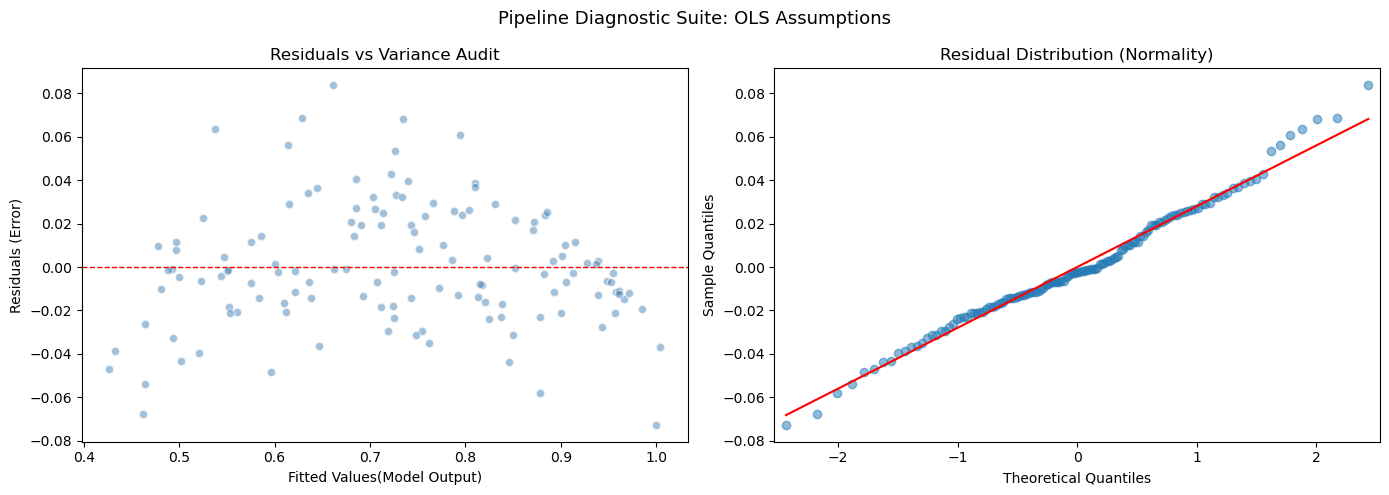

In [8]:
# Residual diagnostic plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs Fitted
axes[0].scatter(model3.fittedvalues, model3.resid, 
                alpha=0.5, color='steelblue', edgecolors='white')
axes[0].axhline(y=0, color='red', linewidth=1, linestyle='--')
axes[0].set_xlabel('Fitted Values(Model Output)')
axes[0].set_ylabel('Residuals (Error)')
axes[0].set_title('Residuals vs Variance Audit')

# Q-Q Plot
sm.qqplot(model3.resid, line='s', ax=axes[1], alpha=0.5)
axes[1].set_title('Residual Distribution (Normality)')

plt.suptitle('Pipeline Diagnostic Suite: OLS Assumptions', fontsize=13)
plt.tight_layout()
plt.show()

## VI Standardized Coefficients & Component Attribution

In [9]:
# Standardize all variables 
# Z-score standardization: mean=0, std=1
reg_data_std = reg_data.copy()

std_vars = ['log_gdp_per_capita', 'log_health_expenditure',
            'mean_years_schooling', 'education_expenditure_pct_gdp',
            'government_effectiveness', 'gii', 'hdi']

for var in std_vars:
    reg_data_std[var] = (reg_data_std[var] - reg_data_std[var].mean()) / reg_data_std[var].std()

# Run OLS on standardized variables
y_std = reg_data_std['hdi']
X3_std = sm.add_constant(reg_data_std[['log_gdp_per_capita', 'log_health_expenditure',
                                        'mean_years_schooling', 'education_expenditure_pct_gdp',
                                        'government_effectiveness', 'gii']])

model3_std = sm.OLS(y_std, X3_std).fit()

# Display standardized coefficients 
std_coef = pd.DataFrame({
    'variable': ['log_gdp_per_capita', 'log_health_expenditure',
                 'mean_years_schooling', 'education_expenditure_pct_gdp',
                 'government_effectiveness', 'gii'],
    'std_coefficient': model3_std.params[1:].values,
    'p_value': model3_std.pvalues[1:].values
}).round(3)

std_coef = std_coef.reindex(std_coef['std_coefficient'].abs().sort_values(ascending=False).index)
print(std_coef.to_string(index=False))

                     variable  std_coefficient  p_value
           log_gdp_per_capita            0.540    0.000
         mean_years_schooling            0.325    0.000
                          gii           -0.240    0.000
       log_health_expenditure           -0.053    0.514
     government_effectiveness           -0.016    0.630
education_expenditure_pct_gdp           -0.013    0.520


In [10]:
std_coef

,variable,std_coefficient,p_value
0,log_gdp_per_capita,0.540,0.000
2,mean_years_schooling,0.325,0.000
5,gii,-0.240,0.000
1,log_health_expenditure,-0.053,0.514
4,government_effectiveness,-0.016,0.630
3,education_expenditure_pct_gdp,-0.013,0.520


### Component Attribution & Signal Strength

The standardized coefficients rank the relative contribution of each data stream to the final Index output. This analysis identifies the primary signals within the integrated pipeline.

- log_gdp_per_capita (β = 0.540):* This is the strongest signal in the model, validating the primary weighting of the income pillar within the HDI framework.

- mean_years_schooling (β = 0.325):* This confirms the secondary importance of educational attainment, showing a stable and precise mapping of UNDP education data.

- gii (β = −0.240):* This represents the strongest external signal. Its high significance confirms that the pipeline successfully incorporated social inequality metrics as a critical adjustment factor.

#### Redundancy Audit (Non-Significant Predictors):

Indicators for health expenditure, government effectiveness, and education spending (β* values near zero) do not provide independent signals. Their information is statistically absorbed by the three primary components, confirming the functional overlap identified in the VIF redundancy audit.

#### Validation Takeaway: 

The attribution results reveal a clear hierarchy: the pipeline is anchored by Economic Core data, followed by Human Capital and Gender Equity metrics. Together, these three streams provide the necessary and sufficient data to reconstruct the Index, while the remaining variables serve as auxiliary indicators with high formulaic redundancy.

### Coefficient Visualization

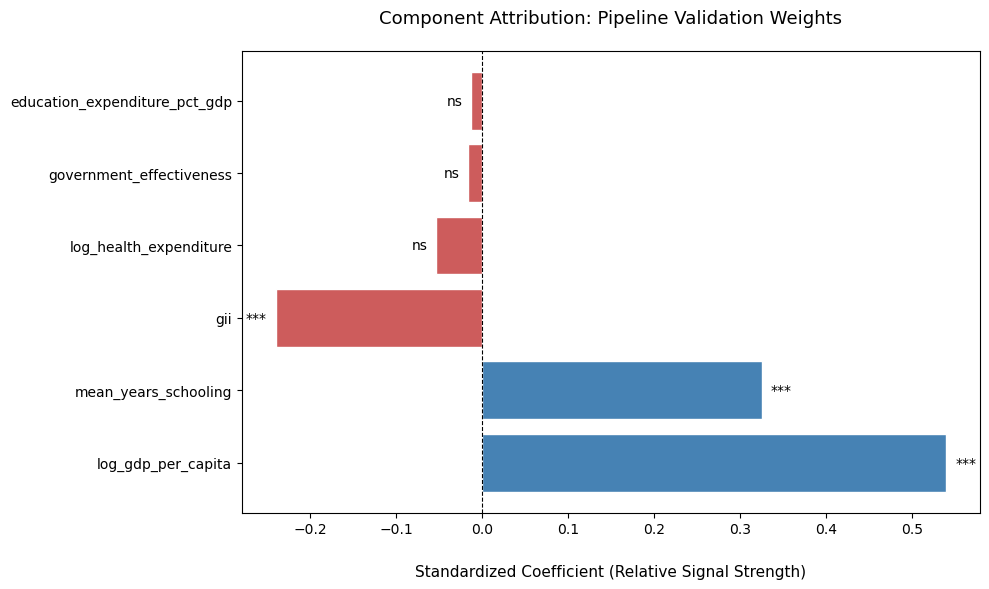

In [11]:
# Visualize standardized coefficients
colors = ['steelblue' if x > 0 else 'indianred' for x in std_coef['std_coefficient']]

plt.figure(figsize=(10, 6))
bars = plt.barh(std_coef['variable'], std_coef['std_coefficient'], 
                color=colors, edgecolor='white')

# Add significance markers 
for i, (val, pval) in enumerate(zip(std_coef['std_coefficient'], std_coef['p_value'])):
    marker = '***' if pval < 0.001 else 'ns'
    plt.text(val + 0.01 if val > 0 else val - 0.01, i, marker, 
             va='center', ha='left' if val > 0 else 'right', fontsize=10)

plt.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
plt.xlabel('Standardized Coefficient (Relative Signal Strength)', fontsize=11, labelpad=20)
plt.title('Component Attribution: Pipeline Validation Weights', fontsize=13, pad=20)
plt.tight_layout()
plt.show()

## Validation Summary
The three statistically significant signals (log GDP per capita, mean years of schooling, GII) confirm that the pipeline has correctly captured and aligned the economic, educational, and social dimensions of human development across sources. The three non-significant variables cluster near zero, confirming functional redundancy identified in the VIF audit. These outputs serve as pipeline validation diagnostics not structural findings or causal claims.